In [ ]:
# Import all library
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import io
from google.colab import files
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout

In [ ]:
uploaded = files.upload()
data = pd.read_csv(io.BytesIO(uploaded['smart_grid_stability.csv']))


Saving smart_grid_stability.csv to smart_grid_stability.csv


In [ ]:
data.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


In [ ]:
# Shuffle the data

data = data.sample(frac = 1) 

In [ ]:
# Define the target coulmn with 1 instead of stable and 0 instead of unstable

Y_data = []
for element in data['stabf']:
    if element == 'stable':
        Y_data.append(1)
    else:
        Y_data.append(0)
Y_data = np.array(Y_data)
Y_data

array([0, 1, 0, ..., 0, 1, 0])

In [ ]:
# Drop trget column

X_data = data.drop(columns=['stab', 'stabf'])

In [ ]:
# Normalize the feature column

X_data_norm = X_data.copy()

for column in X_data_norm.columns:
    X_data_norm[column] = (X_data_norm[column] - X_data_norm[column].mean()) * 1.0 / X_data_norm[column].std()

X_data_norm.describe()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4
count,6.000000e+04,6.000000e+04,6.000000e+04,6.000000e+04,6.000000e+04,6.000000e+04,6.000000e+04,6.000000e+04,6.000000e+04,6.000000e+04,6.000000e+04,6.000000e+04
mean,5.961796e-15,2.742436e-15,2.762521e-14,1.079310e-14,-9.775222e-14,2.825279e-14,5.134233e-14,3.953913e-14,-4.274831e-14,9.286583e-15,1.327057e-14,-2.886451e-15
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-1.731749e+00,-1.731985e+00,-1.731985e+00,-1.731985e+00,-2.881701e+00,-1.731906e+00,-1.731906e+00,-1.731906e+00,-1.731999e+00,-1.731935e+00,-1.731935e+00,-1.731935e+00
25%,-8.660585e-01,-8.660143e-01,-8.660143e-01,-8.660143e-01,-7.069270e-01,-8.660104e-01,-8.660104e-01,-8.660104e-01,-8.659381e-01,-8.660323e-01,-8.660323e-01,-8.660323e-01
50%,1.437158e-06,-7.028671e-06,-7.028671e-06,-7.028671e-06,1.363436e-03,8.877924e-06,8.877925e-06,8.877925e-06,3.412648e-05,2.434658e-05,2.434658e-05,2.434658e-05
75%,8.659059e-01,8.659801e-01,8.659801e-01,8.659801e-01,7.078844e-01,8.660332e-01,8.660332e-01,8.660332e-01,8.657800e-01,8.659828e-01,8.659828e-01,8.659828e-01
max,1.731845e+00,1.731976e+00,1.731976e+00,1.731976e+00,2.811245e+00,1.731977e+00,1.731977e+00,1.731977e+00,1.731805e+00,1.731971e+00,1.731971e+00,1.731971e+00


In [ ]:
print(X_data_norm.shape, "\n", Y_data.shape)

(60000, 12) 
 (60000,)


In [ ]:
# Splitting the dataset into training and testing with 80:20 ratio

X_train, X_test, Y_train, Y_test = train_test_split(X_data_norm, Y_data, train_size=0.8, shuffle=False)

In [ ]:
# Model Creation

model = Sequential()
model.add(Dense(50, input_dim=X_train.shape[1], kernel_initializer='random_normal', activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(40, kernel_initializer='random_normal', activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(30, kernel_initializer='random_normal', activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 50)                650       
                                                                 
 dropout (Dropout)           (None, 50)                0         
                                                                 
 dense_1 (Dense)             (None, 40)                2040      
                                                                 
 dropout_1 (Dropout)         (None, 40)                0         
                                                                 
 dense_2 (Dense)             (None, 30)                1230      
                                                                 
 dropout_2 (Dropout)         (None, 30)                0         
                                                                 
 dense_3 (Dense)             (None, 1)                 3

In [ ]:

model.compile(
    optimizer = tf.keras.optimizers.Adam(),
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)


In [ ]:

history = model.fit(
    x = X_train,
    y = Y_train,
    validation_data=(X_test, Y_test),
    epochs = 20,
    batch_size = 32
)


Epoch 1/20
1500/1500 [==============================] - 5s 3ms/step - loss: 0.3128 - accuracy: 0.8593 - val_loss: 0.1976 - val_accuracy: 0.9183
Epoch 2/20
1500/1500 [==============================] - 4s 2ms/step - loss: 0.2273 - accuracy: 0.9023 - val_loss: 0.1606 - val_accuracy: 0.9378
Epoch 3/20
1500/1500 [==============================] - 3s 2ms/step - loss: 0.2016 - accuracy: 0.9160 - val_loss: 0.1480 - val_accuracy: 0.9382
Epoch 4/20
1500/1500 [==============================] - 4s 2ms/step - loss: 0.1915 - accuracy: 0.9208 - val_loss: 0.1385 - val_accuracy: 0.9461
Epoch 5/20
1500/1500 [==============================] - 3s 2ms/step - loss: 0.1893 - accuracy: 0.9207 - val_loss: 0.1259 - val_accuracy: 0.9511
Epoch 6/20
1500/1500 [==============================] - 3s 2ms/step - loss: 0.1824 - accuracy: 0.9239 - val_loss: 0.1255 - val_accuracy: 0.9523
Epoch 7/20
1500/1500 [==============================] - 4s 2ms/step - loss: 0.1755 - accuracy: 0.9275 - val_loss: 0.1216 - val_accuracy:

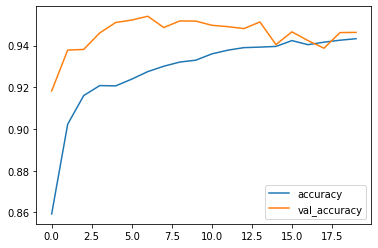

In [ ]:

hist_data = pd.DataFrame(history.history)
hist_data.drop(columns=['loss', 'val_loss'], inplace=True)
hist_data.plot()


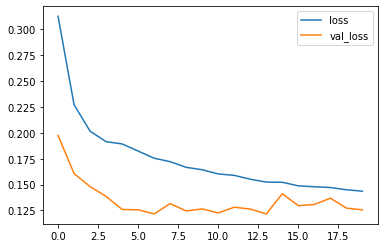

In [ ]:

hist_data = pd.DataFrame(history.history)
hist_data.drop(columns=['accuracy', 'val_accuracy'], inplace=True)
hist_data.plot()



In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
Y_predicted = model.predict(X_test)
Y_predicted[Y_predicted < 0.5] = 0
Y_predicted[Y_predicted >= 0.5] = 1
cm = pd.DataFrame(confusion_matrix(Y_test, Y_predicted))
print("Accuracy of model on Test set", accuracy_score(Y_test, Y_predicted))
print(cm)


Accuracy of model on Test set 0.9463333333333334
      0     1
0  7634    44
1   600  3722
